# Forus DS Take-Home — Part 2: Dermatology Provider Segmentation

**Goal.** Find natural segments in the dermatology provider base, based on the operational characteristics that
drive Provider Operations workload, then turn them into staffing, routing and resource-allocation guidance.

**Approach in one paragraph.** Each prescriber (488) is described by 9 features chosen because they drive support
need: volume, share of biologic/advanced scripts, bridge-program use, payer mix, pediatric share, brand breadth,
pharmacy concentration and practice size. Features are standardized and clustered with k-means. k is chosen on
separation (silhouette, Davies-Bouldin) *and* bootstrap stability, because a segmentation Ops will staff against
has to come out the same when refit. Segments are explained with centroid profiles and a shallow decision tree that
doubles as a routing rule set, then sized in Ops hours using the per-script servicing minutes from Part 1.

**To run:** same as Part 1. Set `BILLING_PROJECT` / `TARGET`, `REBUILD = True` the first time, then *Run all*.

| Layer | Object | Built by |
|---|---|---|
| Source | `tandem-interview.takehome_wu_timothy.prescriptions` | read-only |
| Clean | `derm_rx_clean` | `sql/10_derm_features.sql` |
| Features | `derm_prescriber_features` (1 row per prescriber) | `sql/10_derm_features.sql` |
| Model + ops | clustering, profiles, routing rules, staffing | `forus_segments.py` |
| Output (optional) | `derm_prescriber_segments` | written back by §9 |

## 1. Configuration

In [1]:
BILLING_PROJECT = "tim-wu-personal"                  # project that runs and pays for queries
TARGET          = "tim-wu-personal.forus_analytics"  # project.dataset for the analytics layer
SOURCE          = "tandem-interview.takehome_wu_timothy"
REBUILD         = False   # True = re-run sql/10 (required the first time in a new TARGET)
WRITE_BACK      = False   # True = write segment assignments to {TARGET}.derm_prescriber_segments

K = 4                     # number of segments (see §4 for why)

REPO_URL = "https://github.com/timothywu11/forus.git"  # set to "" if you uploaded the files instead
REPO_DIR = "."

In [2]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import auth
    auth.authenticate_user()
    if REPO_URL:
        # Always sync to the latest code: pull if already cloned, else clone.
        if os.path.exists("forus-takehome/.git"):
            subprocess.run(["git", "-C", "forus-takehome", "pull", "-q"], check=True)
        else:
            subprocess.run(["git", "clone", "-q", REPO_URL, "forus-takehome"], check=True)
        REPO_DIR = "forus-takehome"

sys.path.insert(0, REPO_DIR)
SQL_DIR = os.path.join(REPO_DIR, "sql")
assert os.path.exists(os.path.join(SQL_DIR, "10_derm_features.sql")), \
    f"SQL files not found under {SQL_DIR}; set REPO_URL or REPO_DIR"

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.decomposition import PCA
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

import forus_segments as fs
fs = importlib.reload(fs)   # pick up edits to forus_segments.py without restarting the runtime

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
client = bigquery.Client(project=BILLING_PROJECT)

# Fixed colour per segment (colour follows the segment everywhere; markers add a second cue).
SEG_STYLE = {
    "Biologic Specialists":              ("#2a78d6", "o"),
    "High-Volume Mixed Practices":       ("#eb6834", "s"),
    "Commercial Topical & Acne":         ("#1baf7a", "^"),
    "Generic-Leaning, Government-Payer": ("#eda100", "D"),
}
INK, MUTED, GRID = "#333333", "#777777", "#e6e6e6"

def style_axes(ax):
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#bbbbbb")

## 2. Build and validate the feature layer

In [3]:
def bq(sql: str) -> pd.DataFrame:
    return client.query(sql).to_dataframe()

def run_sql_file(name: str) -> pd.DataFrame:
    with open(os.path.join(SQL_DIR, name)) as f:
        script = f.read().replace("{target}", TARGET)
    job = client.query(script)
    result = job.result()
    print(f"{name}: done, {(job.total_bytes_processed or 0) / 1e9:,.2f} GB processed")
    return result.to_dataframe()

def table_exists(name: str) -> bool:
    try:
        client.get_table(f"{TARGET}.{name}")
        return True
    except NotFound:
        return False

if REBUILD or not table_exists("derm_prescriber_features"):
    display(run_sql_file("10_derm_features.sql"))
else:
    print(f"Reusing existing tables in {TARGET} (set REBUILD = True to rebuild)")

checks = bq(f'''
SELECT
  (SELECT COUNT(*) FROM `{SOURCE}.prescriptions`)                                        AS source_rx,
  (SELECT COUNT(*) FROM `{TARGET}.derm_rx_clean`)                                        AS clean_rx,
  (SELECT COUNT(DISTINCT CAST(hash_prescriber_npi AS STRING)) FROM `{SOURCE}.prescriptions`) AS source_prescribers,
  (SELECT COUNT(*) FROM `{TARGET}.derm_prescriber_features`)                             AS feature_rows,
  (SELECT SUM(n_rx) FROM `{TARGET}.derm_prescriber_features`)                            AS feature_rx
''').T.rename(columns={0: "value"})
display(checks)
v = checks["value"]
assert v["source_rx"] == v["clean_rx"] == v["feature_rx"], "scripts do not reconcile"
assert v["source_prescribers"] == v["feature_rows"], "feature table is not one row per prescriber"
print("Reconciliation checks passed.")

Reusing existing tables in tim-wu-personal.forus_analytics (set REBUILD = True to rebuild)


,value
source_rx,65513
clean_rx,65513
source_prescribers,488
feature_rows,488
feature_rx,65513


Reconciliation checks passed.


## 3. Explore the data and choose features

What the data looks like before modelling. Things that shaped the design:

- **All 65,513 scripts are dermatology**, received Jan–Jul 2025, and monthly volume roughly doubles over the window,
  so volume is measured **per active month**, not as a total.
- **Prior auth is required on ~95% of scripts**, so it hardly varies between prescribers. It's shown in profiles but
  not clustered on.
- **Insurance type is missing or 'UNKNOWN' on 72% of scripts.** Missing benefits information is itself an Ops
  burden, but it's the mirror image of commercial share (r = −0.86), so only commercial share is kept.
- **Every prescriber has at least 35 scripts** (the extract appears to apply a volume floor), so there are no
  near-empty prescribers distorting the features.

In [4]:
feats = fs.prepare(bq(f"SELECT * FROM `{TARGET}.derm_prescriber_features`"))
print(f"{len(feats)} prescribers, {feats['primary_practice_id'].nunique()} primary practices, "
      f"{int(feats['n_rx'].sum()):,} scripts")

monthly = bq(f"SELECT rx_month, COUNT(*) AS scripts FROM `{TARGET}.derm_rx_clean` GROUP BY 1 ORDER BY 1")
display(monthly.set_index("rx_month").T)

print("Clustering features (standardized before k-means):")
display(pd.Series(fs.FEATURES, name="why it matters for Ops").to_frame())
print("Considered and dropped:")
display(pd.Series(fs.DROPPED_FEATURES, name="reason").to_frame())

display(feats[list(fs.FEATURES)].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]])

488 prescribers, 99 primary practices, 65,513 scripts


rx_month,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01
scripts,6355,6967,8223,9581,10023,11738,12626


Clustering features (standardized before k-means):


,why it matters for Ops
f_log_rx_per_month,Volume: scripts per active month (log). Drives...
advanced_share,Complexity: share of biologic / advanced syste...
bridge_rate,Access friction: share of scripts placed on a ...
commercial_share,Payer mix: share with commercial insurance (st...
government_share,Payer mix: share with Medicare / Medicaid / ot...
peds_share,Patient mix: share of patients under 18 (diffe...
f_log_brands,Breadth: distinct brands prescribed (log). Mor...
top_pharmacy_share,Pharmacy concentration: share at the #1 pharma...
f_log_practice_prescribers,Account size: prescribers in the primary pract...


Considered and dropped:


,reason
generic_share,r = -0.77 with advanced_share; would double-we...
unknown_ins_share,r = -0.86 with commercial_share; mirror image ...
pa_rate,PA required on ~95% of scripts; almost no vari...
months_active,"Lifecycle stage (new vs established), not a pr..."


,mean,std,min,25%,50%,75%,max
f_log_rx_per_month,2.924,0.677,1.609,2.460,2.901,3.326,5.342
advanced_share,0.547,0.305,0.000,0.278,0.517,0.827,1.000
bridge_rate,0.024,0.027,0.000,0.000,0.017,0.036,0.158
commercial_share,0.211,0.098,0.010,0.149,0.198,0.259,0.593
government_share,0.082,0.051,0.000,0.045,0.071,0.109,0.333
peds_share,0.099,0.086,0.000,0.046,0.078,0.130,0.736
f_log_brands,2.872,0.417,1.099,2.639,2.890,3.135,4.174
top_pharmacy_share,0.301,0.122,0.110,0.215,0.280,0.364,0.925
f_log_practice_prescribers,2.189,0.986,0.000,1.386,2.485,2.944,3.367


In [5]:
# Correlations among candidate features (why generic_share and unknown_ins_share were dropped)
cand = list(fs.FEATURES) + ["generic_share", "unknown_ins_share"]
feats[cand].corr().round(2)

,f_log_rx_per_month,advanced_share,bridge_rate,commercial_share,government_share,peds_share,f_log_brands,top_pharmacy_share,f_log_practice_prescribers,generic_share,unknown_ins_share
f_log_rx_per_month,1.000,-0.370,-0.210,-0.030,-0.080,0.230,0.580,-0.120,0.000,0.400,0.080
advanced_share,-0.370,1.000,0.490,-0.130,0.160,-0.350,-0.200,0.320,0.010,-0.770,0.040
bridge_rate,-0.210,0.490,1.000,0.190,-0.030,-0.200,-0.090,0.170,-0.020,-0.430,-0.180
commercial_share,-0.030,-0.130,0.190,1.000,-0.250,0.120,0.270,0.020,-0.020,-0.330,-0.860
government_share,-0.080,0.160,-0.030,-0.250,1.000,-0.030,-0.110,-0.070,0.010,-0.060,-0.270
peds_share,0.230,-0.350,-0.200,0.120,-0.030,1.000,0.030,0.040,-0.070,0.240,-0.110
f_log_brands,0.580,-0.200,-0.090,0.270,-0.110,0.030,1.000,-0.210,0.210,0.000,-0.210
top_pharmacy_share,-0.120,0.320,0.170,0.020,-0.070,0.040,-0.210,1.000,-0.050,-0.280,0.020
f_log_practice_prescribers,0.000,0.010,-0.020,-0.020,0.010,-0.070,0.210,-0.050,1.000,-0.030,0.020
generic_share,0.400,-0.770,-0.430,-0.330,-0.060,0.240,0.000,-0.280,-0.030,1.000,0.360


## 4. How many segments?

Four criteria, because no single one is decisive on behavioural data like this:

- **Silhouette** (higher is better) and **Davies-Bouldin** (lower is better) measure separation.
- **Bootstrap stability** refits on random 80% samples and checks the segments come back the same (adjusted Rand
  index; 1 = identical). A segmentation Ops staffs against must be stable.
- **Smallest segment** guards against a segment too small to justify its own queue.

Silhouette is low for every k (0.8),
has the best Davies-Bouldin of k ≤ 5, and splits out a distinct commercial/topical group that k = 3 absorbs.
Stability falls sharply from k = 5.

,inertia,silhouette,davies_bouldin,bootstrap_ari_mean,bootstrap_ari_min,smallest_segment
k,,,,,,
2,"3,643.998",0.170,1.996,0.900,0.552,184
3,"3,262.741",0.144,2.051,0.784,0.383,159
4,"2,999.494",0.147,1.852,0.835,0.588,55
5,"2,807.913",0.141,1.921,0.620,0.298,50
6,"2,621.439",0.127,1.828,0.586,0.349,36
7,"2,472.627",0.140,1.686,0.475,0.310,6
8,"2,323.449",0.144,1.636,0.620,0.446,5


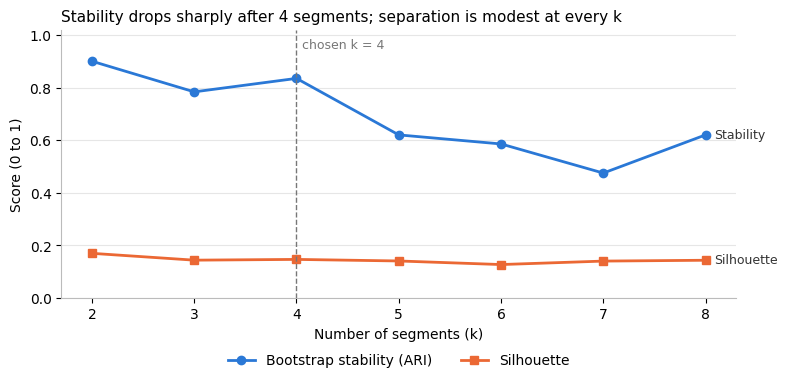

In [6]:
kt = fs.evaluate_k(feats, ks=range(2, 9), n_boot=30)
display(kt)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(kt.index, kt["bootstrap_ari_mean"], color="#2a78d6", linewidth=2, marker="o", label="Bootstrap stability (ARI)")
ax.plot(kt.index, kt["silhouette"], color="#eb6834", linewidth=2, marker="s", label="Silhouette")
for col, lab in (("bootstrap_ari_mean", "Stability"), ("silhouette", "Silhouette")):
    ax.annotate(lab, (kt.index[-1], kt[col].iloc[-1]), xytext=(6, 0), textcoords="offset points",
                va="center", color=INK, fontsize=9)
ax.axvline(K, color=MUTED, linestyle="--", linewidth=1)
ax.annotate(f"chosen k = {K}", (K, 0.95), xytext=(4, 0), textcoords="offset points", color=MUTED, fontsize=9)
ax.set_xlabel("Number of segments (k)")
ax.set_ylabel("Score (0 to 1)")
ax.set_ylim(0, 1.02)
ax.set_title("Stability drops sharply after 4 segments; separation is modest at every k", loc="left", fontsize=11)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)
style_axes(ax)
plt.tight_layout(); plt.show()

## 5. Fit the segments

In [7]:
seg = fs.fit_segments(feats, k=K)
feats["segment"] = seg.labels

sizes = feats.groupby("segment").agg(prescribers=("prescriber_id", "size"), scripts=("n_rx", "sum"),
                                     practices=("primary_practice_id", "nunique"))
sizes["share_of_prescribers"] = sizes["prescribers"] / sizes["prescribers"].sum()
sizes["share_of_scripts"] = sizes["scripts"] / sizes["scripts"].sum()
sizes.sort_values("scripts", ascending=False)

,prescribers,scripts,practices,share_of_prescribers,share_of_scripts
segment,,,,,
High-Volume Mixed Practices,152,34884,31,0.311,0.532
Biologic Specialists,166,15473,55,0.340,0.236
"Generic-Leaning, Government-Payer",115,9291,50,0.236,0.142
Commercial Topical & Acne,55,5865,35,0.113,0.090


## 6. What each segment looks like

The heatmap shows each segment's centroid in standard deviations from the average prescriber
(blue = above average, red = below). The table below gives medians in real units.

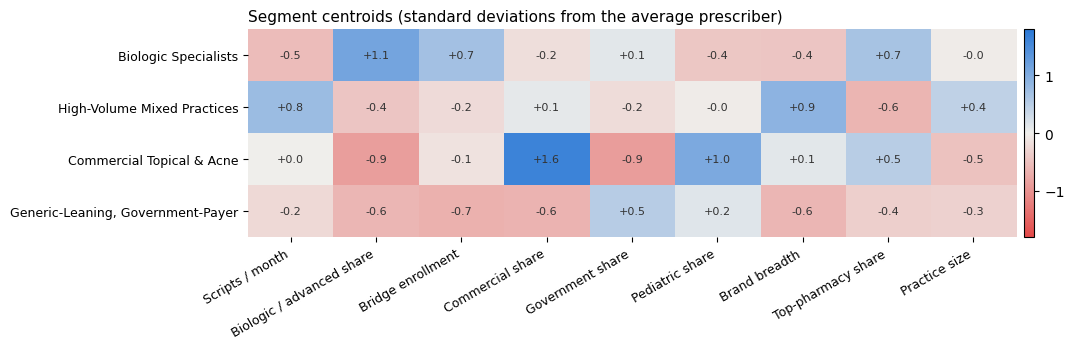

segment,Biologic Specialists,Commercial Topical & Acne,"Generic-Leaning, Government-Payer",High-Volume Mixed Practices
rx_per_month,12.708,20.000,16.200,29.536
n_rx,71.500,77.000,69.000,167.500
advanced_share,0.931,0.239,0.354,0.432
generic_share,0.004,0.132,0.349,0.243
branded_other_share,0.042,0.525,0.245,0.287
bridge_rate,0.038,0.017,0.000,0.014
commercial_share,0.188,0.364,0.146,0.214
government_share,0.082,0.038,0.099,0.061
unknown_ins_share,0.714,0.603,0.733,0.714
peds_share,0.051,0.158,0.099,0.082


In [8]:
labels_pretty = {
    "f_log_rx_per_month": "Scripts / month", "advanced_share": "Biologic / advanced share",
    "bridge_rate": "Bridge enrollment", "commercial_share": "Commercial share",
    "government_share": "Government share", "peds_share": "Pediatric share",
    "f_log_brands": "Brand breadth", "top_pharmacy_share": "Top-pharmacy share",
    "f_log_practice_prescribers": "Practice size",
}
z = seg.centers.rename(columns=labels_pretty)
cmap = LinearSegmentedColormap.from_list("div", ["#e34948", "#f0efec", "#2a78d6"])
fig, ax = plt.subplots(figsize=(11, 3.6))
im = ax.imshow(z.values, cmap=cmap, vmin=-1.8, vmax=1.8, aspect="auto")
ax.set_xticks(range(z.shape[1]), z.columns, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(z.shape[0]), z.index, fontsize=9)
for i in range(z.shape[0]):
    for j in range(z.shape[1]):
        ax.text(j, i, f"{z.values[i, j]:+.1f}", ha="center", va="center", fontsize=8, color=INK)
ax.set_title("Segment centroids (standard deviations from the average prescriber)", loc="left", fontsize=11)
for s in ax.spines.values(): s.set_visible(False)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
plt.tight_layout(); plt.show()

fs.profile(feats, seg.labels)

In [9]:
# Top brands per segment (sanity check on the names)
top_brands = bq(f'''
SELECT prescriber_id, brand_name, COUNT(*) AS n
FROM `{TARGET}.derm_rx_clean` GROUP BY 1, 2
''').merge(seg.assignments[["prescriber_id", "segment"]], on="prescriber_id")
tb = (top_brands.groupby(["segment", "brand_name"])["n"].sum()
      .groupby(level=0, group_keys=False).apply(lambda s: (s / s.sum()).nlargest(6)))
tb.rename("share_of_segment_scripts").to_frame()

share_of_segment_scripts
segment                           brand_name                          
Biologic Specialists              Dupixent                       0.244
                                  Skyrizi                        0.189
                                  Tremfya                        0.070
                                  Taltz                          0.053
                                  Cosentyx                       0.049
                                  Rinvoq                         0.039
Commercial Topical & Acne         Generic                        0.156
                                  Dupixent                       0.093
                                  Zoryve                         0.081
                                  Cabtreo                        0.057
                                  Winlevi                        0.050
                                  Opzelura                       0.046
Generic-Leaning, Government-Payer Generic                        0.419
                                  Dupixent                       0.121
                                  Skyrizi                        0.065
                                  Zoryve                         0.052
                                  Opzelura                       0.040
                                  Tremfya                        0.034
High-Volume Mixed Practices       Generic                        0.399
                                  Dupixent                       0.103
                                  Skyrizi                        0.057
                                  Zoryve                         0.054
                                  Opzelura                       0.038
                                  Tremfya                        0.029

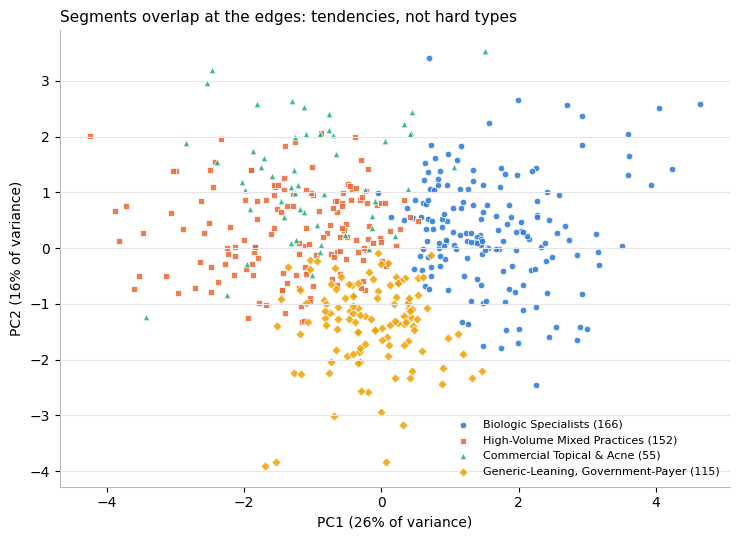

In [10]:
# 2-D view (PCA projection of the 9 standardized features; axes are combinations of features)
X = seg.scaler.transform(feats[seg.features])
pca = PCA(2, random_state=0).fit(X)
P = pca.transform(X)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for name, (color, marker) in SEG_STYLE.items():
    m = feats["segment"].to_numpy() == name
    ax.scatter(P[m, 0], P[m, 1], s=22, c=color, marker=marker, edgecolors="white", linewidths=0.6,
               alpha=0.85, label=f"{name} ({m.sum()})")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} of variance)")
ax.set_title("Segments overlap at the edges: tendencies, not hard types", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="best")
style_axes(ax)
plt.tight_layout(); plt.show()

## 7. Interpretability and evaluation

**Routing rules.** A depth-3 decision tree trained to reproduce the segments from raw, unscaled features. Its
cross-validated agreement with k-means shows how much of the segmentation a handful of thresholds captures. These
rules are what Ops would actually use to route a new provider, no model required.

**Robustness.** Agreement between k-means and two other algorithms on the same features. Moderate agreement
confirms the main structure (especially the Biologic Specialists segment) while signalling that the boundaries
between the other segments are soft.

In [11]:
rules, cv_agreement, tree = fs.routing_rules(feats, seg.labels, max_depth=3)
print(f"Cross-validated agreement of the 3-level rule set with k-means: {cv_agreement:.0%}\n")
print(rules)
display(fs.robustness(feats, seg.labels, k=K).to_frame())

Cross-validated agreement of the 3-level rule set with k-means: 78%

|--- advanced_share <= 0.72
|   |--- n_brands <= 19.50
|   |   |--- commercial_share <= 0.25
|   |   |   |--- class: Generic-Leaning, Government-Payer
|   |   |--- commercial_share >  0.25
|   |   |   |--- class: Commercial Topical & Acne
|   |--- n_brands >  19.50
|   |   |--- branded_other_share <= 0.60
|   |   |   |--- class: High-Volume Mixed Practices
|   |   |--- branded_other_share >  0.60
|   |   |   |--- class: Commercial Topical & Acne
|--- advanced_share >  0.72
|   |--- advanced_share <= 0.80
|   |   |--- rx_per_month <= 20.79
|   |   |   |--- class: Biologic Specialists
|   |   |--- rx_per_month >  20.79
|   |   |   |--- class: High-Volume Mixed Practices
|   |--- advanced_share >  0.80
|   |   |--- top_pharmacy_share <= 0.27
|   |   |   |--- class: Biologic Specialists
|   |   |--- top_pharmacy_share >  0.27
|   |   |   |--- class: Biologic Specialists



,adjusted_rand_vs_kmeans
ward_hierarchical,0.383
gaussian_mixture,0.406


## 8. What it means for Provider Operations

Workload uses the Part 1 servicing assumptions (30 minutes per biologic/advanced script, 10 minutes otherwise) and
treats every script in this data as serviced by Forus, since it is Forus's own prescription data.

In [12]:
display(fs.OPS_PLAYBOOK)

rx_monthly = bq(f'''
SELECT prescriber_id, CAST(rx_month AS STRING) AS rx_month, drug_class, COUNT(*) AS n
FROM `{TARGET}.derm_rx_clean` GROUP BY 1, 2, 3
''')
wl = fs.workload(rx_monthly, seg.assignments)
latest = wl.index.get_level_values("rx_month").max()
current = wl.xs(latest, level="rx_month")
print(f"Ops workload in {latest} (latest month):")
display(current.assign(share_of_hours=current["hours"] / current["hours"].sum()))

,support_need,queue,staffing_driver
segment,,,
Biologic Specialists,"Complex access: biologic PAs, appeals, bridge ...","Specialty access queue (senior PA specialists,...",Hours per script (30 min); highest bridge and ...
High-Volume Mixed Practices,Throughput across many brands and pharmacies; ...,Dedicated account pods with batching and autom...,Script volume; largest share of total hours
Commercial Topical & Acne,Step-therapy and formulary exceptions for bran...,Commercial formulary queue (templated step-the...,"Moderate volume, low per-script complexity"
"Generic-Leaning, Government-Payer",Mostly routine generic PAs; Medicare/Medicaid ...,Standard queue with templates; onboarding trac...,Low hours per prescriber; onboarding effort fr...


Ops workload in 2025-07-01 (latest month):


,scripts,hours,active_prescribers,hours_per_prescriber,fte,share_of_hours
segment,,,,,,
Biologic Specialists,2503,"1,163.167",164,7.092,7.754,0.296
Commercial Topical & Acne,1403,349.833,53,6.601,2.332,0.089
"Generic-Leaning, Government-Payer",2303,636.500,112,5.683,4.243,0.162
High-Volume Mixed Practices,6417,"1,777.500",150,11.850,11.850,0.453


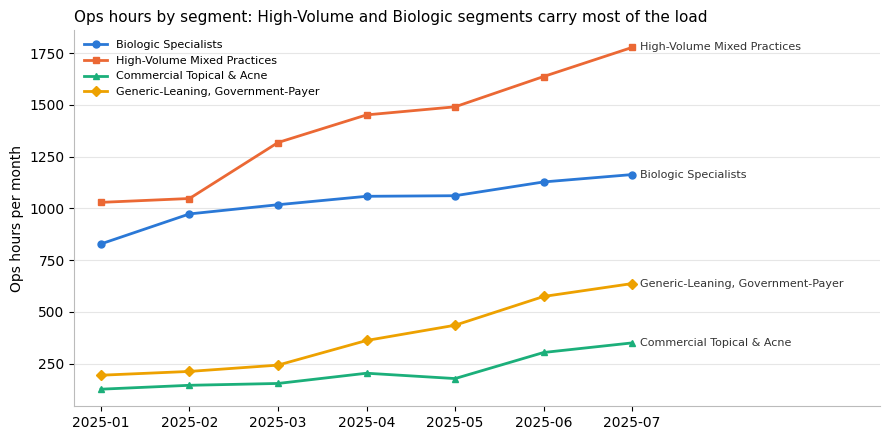

In [13]:
# Monthly Ops hours by segment
hours = wl["hours"].unstack("segment")
fig, ax = plt.subplots(figsize=(9, 4.5))
for name, (color, marker) in SEG_STYLE.items():
    if name in hours:
        ax.plot(range(len(hours)), hours[name], color=color, marker=marker, linewidth=2, markersize=5, label=name)
        ax.annotate(name, (len(hours) - 1, hours[name].iloc[-1]), xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=8, color=INK)
ax.set_xticks(range(len(hours)), [m[:7] for m in hours.index])
ax.set_ylabel("Ops hours per month")
ax.set_title("Ops hours by segment: High-Volume and Biologic segments carry most of the load", loc="left", fontsize=11)
ax.set_xlim(-0.3, len(hours) + 1.8)
ax.legend(frameon=False, fontsize=8, loc="upper left")
style_axes(ax)
plt.tight_layout(); plt.show()

**Staffing forecast.** Change `GROWTH` to see FTE needs as the provider base scales. It assumes hours per
prescriber stay at the latest month's level. Growth is set per segment because GTM choices (e.g. Part 1's focus
on biologic-heavy practices) change the mix, not just the size.

In [14]:
GROWTH = {
    "Biologic Specialists": 2.0,
    "High-Volume Mixed Practices": 1.5,
    "Commercial Topical & Acne": 1.0,
    "Generic-Leaning, Government-Payer": 1.0,
}
fs.staffing_forecast(current, GROWTH)

,active_prescribers,hours_per_prescriber,growth,future_prescribers,future_hours,current_fte,future_fte
segment,,,,,,,
Biologic Specialists,164.000,7.092,2.000,328.000,"2,326.333",7.754,15.509
Commercial Topical & Acne,53.000,6.601,1.000,53.000,349.833,2.332,2.332
"Generic-Leaning, Government-Payer",112.000,5.683,1.000,112.000,636.500,4.243,4.243
High-Volume Mixed Practices,150.000,11.850,1.500,225.000,"2,666.250",11.850,17.775
Total,479.000,<NA>,NaN,718.000,"5,978.917",26.180,39.859


**Practice-level routing.** Ops manages practices, not individual prescribers. Practices where at least 75% of
prescribers share a segment route as a whole; the rest route per prescriber.

In [15]:
pr = fs.practice_rollup(seg.assignments, feats)
display(pr["routing"].value_counts().to_frame("practices"))
display(pr.groupby("dominant_segment").agg(practices=("prescribers", "size"), prescribers=("prescribers", "sum")))
pr.head(15)

,practices
routing,
route as practice,70
mixed: route per prescriber,29


,practices,prescribers
dominant_segment,,
Biologic Specialists,35,139
Commercial Topical & Acne,18,40
"Generic-Leaning, Government-Payer",31,114
High-Volume Mixed Practices,15,195


,prescribers,dominant_segment,dominant_share,scripts,routing
primary_practice_id,,,,,
290f72ab-88c8-4180-8cd6-bd27c406d92a,28,High-Volume Mixed Practices,0.500,3983,mixed: route per prescriber
3ac24c75-8150-4567-b4c7-3f63745d5a04,24,High-Volume Mixed Practices,0.458,2748,mixed: route per prescriber
be10d00e-9cbf-4694-9ca7-f8e345ac4a95,24,Biologic Specialists,0.833,2491,route as practice
1f667954-5580-43c8-976f-172f90a97829,22,High-Volume Mixed Practices,0.773,3253,route as practice
869430b8-dfe3-4cb6-a0ad-a42083ba0722,21,High-Volume Mixed Practices,0.571,3909,mixed: route per prescriber
94e62955-154c-4450-af9b-7e372819c2ab,19,Biologic Specialists,1.000,2410,route as practice
79eafddf-e67e-4111-8917-0bfe9f61a8f0,17,High-Volume Mixed Practices,0.647,4927,mixed: route per prescriber
07cfa7ac-868c-4bb3-90cc-0ed674dee7d1,15,Biologic Specialists,0.400,1369,mixed: route per prescriber
aaa6c2b9-2846-4367-b7a8-5db9e251a129,15,High-Volume Mixed Practices,0.467,2719,mixed: route per prescriber


## 9. Save segment assignments (optional)

In [16]:
if WRITE_BACK:
    out = seg.assignments.merge(feats[["prescriber_id"] + list(fs.FEATURES)], on="prescriber_id")
    job = client.load_table_from_dataframe(
        out, f"{TARGET}.derm_prescriber_segments",
        job_config=bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE"))
    job.result()
    print(f"Wrote {len(out)} rows to {TARGET}.derm_prescriber_segments")
else:
    print("WRITE_BACK = False: assignments kept in memory only (seg.assignments)")

WRITE_BACK = False: assignments kept in memory only (seg.assignments)


## Notes and caveats

- **Soft boundaries.** Silhouette is ~0.15 and agreement with other algorithms is moderate. Treat segments as
  tendencies for staffing and routing, and use the rule set (§7) so assignments are explainable and adjustable.
- **Short window.** Seven months (Jan–Jul 2025) of a growing book; newer prescribers have fewer months of history.
  `months_active` is kept as an onboarding overlay rather than a clustering feature.
- **Prescriber IDs** are stored as FLOAT64 in the source (the dictionary says INTEGER), which loses precision on
  large hashes. Distinct counts still match (488), so IDs are used as-is.
- **Servicing minutes** reuse the Part 1 prompt (30 / 10). Real handle times by segment would sharpen the
  staffing model and are the first thing to measure.
- **Refresh.** Re-running the notebook on new data refits the segments; `seg.predict()` assigns new prescribers to
  the existing segments without refitting, so queues stay stable between planned refreshes.